##Premium Quote Prediction - Car

##Workflow

1. Import libraries
2. Load dataset
3. Data inspection (head, info, describe)
4. Duplicate analysis
5. Missing value analysis
6. Exploratory Data Analysis (visualizations)
7. Train/test split
8. Build preprocessing + model pipeline
9. Train the model
10. Evaluation (MAE, RMSE, R²)
11. Save the trained pipeline

##Import libraries



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##Load Dataset

In [5]:
df_car = pd.read_csv('/content/acko_car_quotation.csv')



##Data inspection

In [6]:
df_car.shape

#(200000, 28)

(200000, 28)

In [7]:
df_car.head()

,record_id,customer_age,city,state,city_tier,city_risk_score,vehicle_make,vehicle_model,variant,segment,...,policy_type,previous_insurer,num_addons,addons_list,od_premium_before_ncb,ncb_discount_amount,tp_premium,addon_premium,gst_amount,annual_premium
0,d96cac39,26,Kolkata,West Bengal,1,1.40,Honda,Amaze,Deluxe,sedan,...,Third Party,Tata AIG,0,NaN,13543.01,6771.51,3416,0.00,614.88,4212
1,8a5e47cd,59,Panaji,Goa,3,0.95,Mercedes-Benz,A-Class Limousine,Sport,sedan,...,Comprehensive,Acko,3,"Personal Accident Cover, Return to Invoice, Ke...",133631.52,66815.76,3416,3192.95,14419.13,95457
2,653b7fa5,40,Bhopal,Madhya Pradesh,2,1.12,Nissan,Magnite,Turbo,suv,...,Third Party,Reliance General,4,"Personal Accident Cover, Roadside Assistance, ...",11130.53,2782.63,2094,7474.75,376.92,2385
3,b3ec92ca,32,Madurai,Tamil Nadu,2,1.10,Ford,Aspire,Long Range,sedan,...,Third Party,Tata AIG,1,Return to Invoice,10674.04,2668.51,3416,1076.51,614.88,4178
4,43ef7ada,61,Thiruvananthapuram,Kerala,3,1.00,Ford,Aspire,Deluxe,sedan,...,Comprehensive,Bajaj Allianz,1,Consumables Cover,9590.42,4795.21,3416,1173.35,1858.14,12434


In [8]:
df_car.columns

Index(['record_id', 'customer_age', 'city', 'state', 'city_tier',
       'city_risk_score', 'vehicle_make', 'vehicle_model', 'variant',
       'segment', 'fuel_type', 'colour', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'policy_type', 'previous_insurer', 'num_addons',
       'addons_list', 'od_premium_before_ncb', 'ncb_discount_amount',
       'tp_premium', 'addon_premium', 'gst_amount', 'annual_premium'],
      dtype='object')

In [9]:
df_car.describe()

,customer_age,city_tier,city_risk_score,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,num_addons,od_premium_before_ncb,ncb_discount_amount,tp_premium,addon_premium,gst_amount,annual_premium
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,2.000000e+05
mean,46.524740,2.435315,1.031174,2014.507050,10.492950,1312.327660,1.513422e+06,29.180800,0.882015,1.449935,6.334452e+04,18484.230142,4172.324945,2390.242746,7923.206599,5.193187e+04
std,16.748066,0.617865,0.160228,5.762987,5.762987,776.538865,2.149447e+06,16.681436,1.092863,1.161572,8.748986e+04,31111.599229,2391.727211,2119.675971,12438.922308,8.155203e+04
min,18.000000,1.000000,0.820000,2005.000000,1.000000,0.000000,9.469100e+04,0.000000,0.000000,0.000000,3.219370e+03,0.000000,2094.000000,0.000000,376.920000,2.347000e+03
25%,32.000000,2.000000,0.900000,2010.000000,5.000000,999.000000,3.414438e+05,20.000000,0.000000,0.000000,1.546649e+04,3110.760000,2094.000000,0.000000,1563.610000,1.024800e+04
50%,47.000000,3.000000,1.000000,2014.000000,11.000000,1199.000000,6.870595e+05,35.000000,0.000000,1.000000,2.862012e+04,7501.930000,3416.000000,2033.225000,3610.190000,2.366000e+04
75%,61.000000,3.000000,1.120000,2020.000000,15.000000,1956.000000,1.775388e+06,45.000000,2.000000,2.000000,7.716096e+04,20809.437500,7897.000000,3732.000000,8923.302500,5.840250e+04
max,75.000000,3.000000,1.500000,2024.000000,20.000000,3346.000000,2.373989e+07,50.000000,4.000000,4.000000,1.229050e+06,525316.160000,7897.000000,9999.010000,244980.860000,1.607449e+06


In [10]:
df_car.describe(include='object')

,record_id,city,state,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,policy_type,previous_insurer,addons_list
count,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,177879,149860
unique,199994,117,32,18,134,29,6,6,16,3,8,5140
top,c8d6bba8,Amritsar,Maharashtra,Mercedes-Benz,Magnite,Matic,suv,Petrol,Midnight Black,Comprehensive,ICICI Lombard,Engine Protection
freq,2,1793,25522,11308,10989,7038,95272,91604,12669,129973,22405,6107


In [11]:
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   record_id              200000 non-null  object 
 1   customer_age           200000 non-null  int64  
 2   city                   200000 non-null  object 
 3   state                  200000 non-null  object 
 4   city_tier              200000 non-null  int64  
 5   city_risk_score        200000 non-null  float64
 6   vehicle_make           200000 non-null  object 
 7   vehicle_model          200000 non-null  object 
 8   variant                200000 non-null  object 
 9   segment                200000 non-null  object 
 10  fuel_type              200000 non-null  object 
 11  colour                 200000 non-null  object 
 12  manufacturing_year     200000 non-null  int64  
 13  vehicle_age_years      200000 non-null  int64  
 14  engine_cc              200000 non-nu

##Duplicate Analysis

In [12]:
df_car.duplicated().sum()

np.int64(0)

In [13]:
df_car.drop(columns=['record_id']).duplicated().sum()

np.int64(0)

##Missing Value Analysis

In [14]:
df_car.isna().sum()

,0
record_id,0
customer_age,0
city,0
state,0
city_tier,0
city_risk_score,0
vehicle_make,0
vehicle_model,0
variant,0
segment,0


In [15]:
df_car['previous_insurer'].head()

,previous_insurer
0,Tata AIG
1,Acko
2,Reliance General
3,Tata AIG
4,Bajaj Allianz


In [16]:
df_car['addons_list'].head()

,addons_list
0,NaN
1,"Personal Accident Cover, Return to Invoice, Ke..."
2,"Personal Accident Cover, Roadside Assistance, ..."
3,Return to Invoice
4,Consumables Cover


In [17]:
df_car["previous_insurer"] = df_car["previous_insurer"].fillna(
    df_car["previous_insurer"].mode()[0]
)

In [18]:
df_car['previous_insurer'].isna().sum()

np.int64(0)

##Inference

Inference: The previous_insurer column contained approximately 11.06% missing values. Unlike the addons_list column, the missing values in previous_insurer did not follow a clear business pattern, as they were associated with customers having different NCB percentages (0%, 20%, 25%, 35%, 45%, and 50%). Therefore, these null values were treated as genuine missing categorical data rather than representing a specific business condition. Since the percentage of missing values was relatively low and the column is categorical, the missing values were imputed using the mode (most frequently occurring insurer) to preserve the dataset's consistency before model training.

##Imputing Null values in 'previous_insurer'

In [19]:
df_car['previous_insurer'].isna().mean()*100

np.float64(0.0)

In [20]:
df_car[df_car["previous_insurer"].isna()].head()

,record_id,customer_age,city,state,city_tier,city_risk_score,vehicle_make,vehicle_model,variant,segment,...,policy_type,previous_insurer,num_addons,addons_list,od_premium_before_ncb,ncb_discount_amount,tp_premium,addon_premium,gst_amount,annual_premium


In [21]:
df_car.loc[df_car["previous_insurer"].isna(), "ncb_percent"].value_counts()

,count
ncb_percent,


In [22]:
(df_car.loc[df_car["previous_insurer"].isna(), "ncb_percent"] == 0).all()

np.True_

##Imputing Null values in 'addons_list'

In [23]:
df_car['addons_list'].isna().mean()*100

np.float64(25.069999999999997)

In [24]:
df_car.loc[df_car['addons_list'].isna(), "num_addons"].value_counts()

,count
num_addons,
0,50140


In [25]:
(df_car.loc[df_car["addons_list"].isna(), "num_addons"] == 0).all()

np.True_

In [26]:
df_car["addons_list"] = df_car["addons_list"].fillna("No Add-ons")

In [27]:
df_car['addons_list'].isna().sum()

np.int64(0)

##Inference

 Inference : The addons_list column contains null values only for customers with num_addons = 0. Therefore, these null values indicate that no add-ons were selected rather than missing information. Hence, they were replaced with "No Add-ons".

##Exploratory Data Analysis(Visualization)

#1. Distribution of Target Variable (Annual Premium)

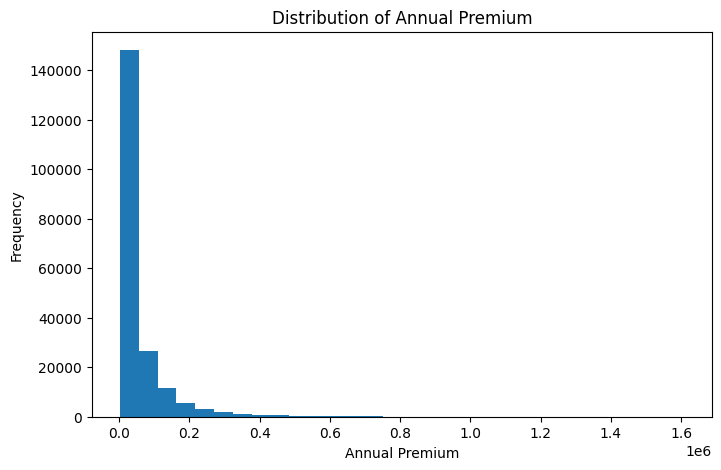

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df_car["annual_premium"], bins=30)

plt.title("Distribution of Annual Premium")
plt.xlabel("Annual Premium")
plt.ylabel("Frequency")

plt.show()

#Inference

The distribution of the annual premium is highly right-skewed, indicating that most policyholders pay relatively lower premiums while only a small proportion of customers have very high premium amounts. This suggests the presence of high-value vehicles and premium policies that contribute to the long tail of the distribution.

#2. IDV vs Annual Premium (Scatter Plot)

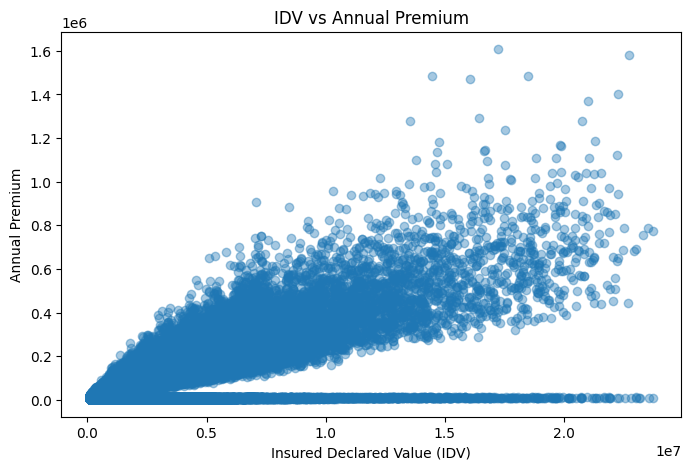

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df_car["idv"],
            df_car["annual_premium"],
            alpha=0.4)

plt.title("IDV vs Annual Premium")
plt.xlabel("Insured Declared Value (IDV)")
plt.ylabel("Annual Premium")

plt.show()

#Inference

A clear positive relationship is observed between the Insured Declared Value (IDV) and the annual premium. As the insured value of the vehicle increases, the premium generally increases because higher-value vehicles represent greater financial risk to the insurer. A few scattered points indicate that additional factors such as policy type, add-ons, and claim history also influence the final premium.

#3. Vehicle Age vs Annual Premium

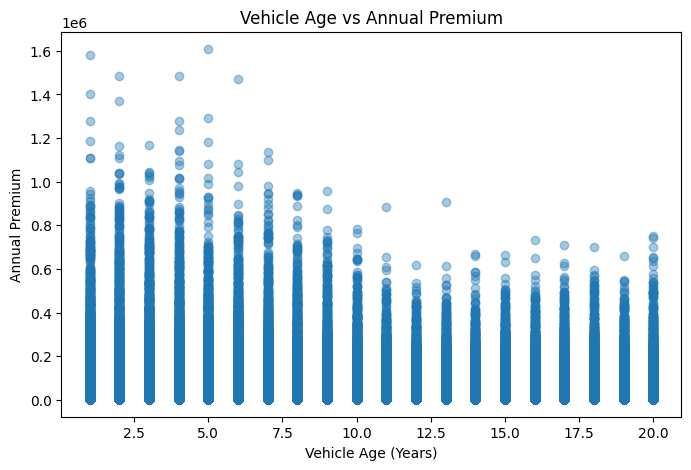

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df_car["vehicle_age_years"],
            df_car["annual_premium"],
            alpha=0.4)

plt.title("Vehicle Age vs Annual Premium")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Annual Premium")

plt.show()

#Inference

Vehicle age exhibits a moderate negative relationship with the annual premium. Newer vehicles generally have higher premiums due to their higher market value, whereas older vehicles tend to have lower premiums as their insured value depreciates over time. However, the spread of points indicates that premium calculation also depends on several other customer and vehicle-related factors.

#4. Correlation Heatmap (Numeric Features)

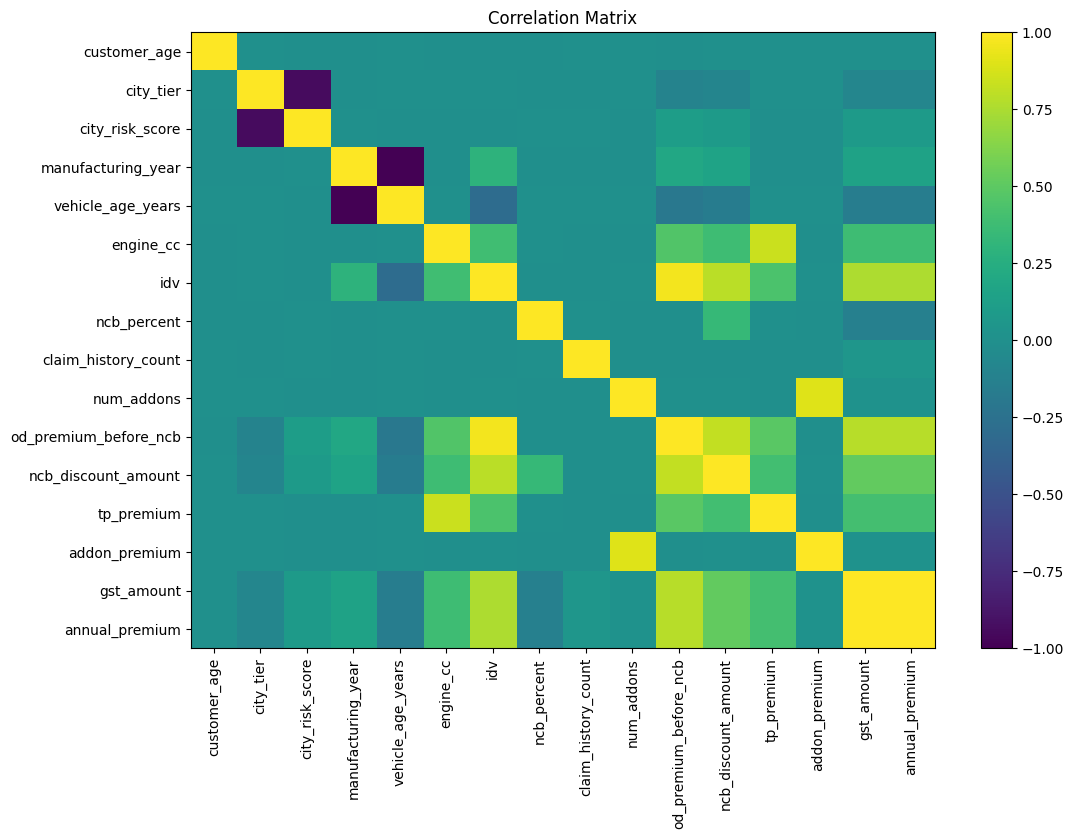

In [31]:
numeric_df = df_car.select_dtypes(include="number")

plt.figure(figsize=(12,8))

plt.imshow(numeric_df.corr(),
           aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Matrix")

plt.show()

#Inference

The correlation matrix shows strong positive relationships between Annual Premium and features such as IDV, Own Damage Premium, GST Amount, and Third Party Premium, indicating that these variables significantly influence the premium calculation. A strong negative correlation is observed between Manufacturing Year and Vehicle Age, which is expected since newer vehicles have lower ages. Most other features exhibit weak to moderate correlations, suggesting that the premium is determined by the combined effect of multiple variables rather than any single feature.

#5. Average Annual Premium by Policy Type

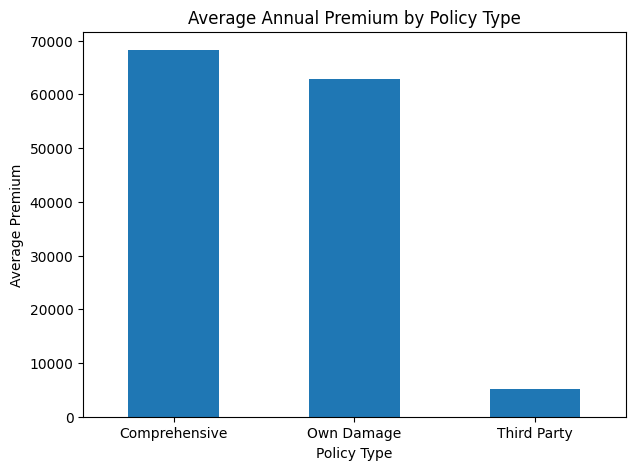

In [32]:
plt.figure(figsize=(7,5))

df_car.groupby("policy_type")["annual_premium"].mean().plot(kind="bar")

plt.title("Average Annual Premium by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Average Premium")

plt.xticks(rotation=0)

plt.show()

#Inference

The average annual premium is highest for Comprehensive policies, followed by Own Damage policies, while Third Party policies have the lowest average premium. This is expected because comprehensive policies provide the widest coverage, including own vehicle damage and third-party liability, resulting in higher insurance costs.

##Imports for Model Building

In [33]:
#Data Preprocessing

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Model Building

from sklearn.ensemble import RandomForestRegressor

#Evaluation Metrics

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score


##Splitting Feature Columns(X) and Target Column(Y)

In [34]:
df_car.columns

Index(['record_id', 'customer_age', 'city', 'state', 'city_tier',
       'city_risk_score', 'vehicle_make', 'vehicle_model', 'variant',
       'segment', 'fuel_type', 'colour', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'policy_type', 'previous_insurer', 'num_addons',
       'addons_list', 'od_premium_before_ncb', 'ncb_discount_amount',
       'tp_premium', 'addon_premium', 'gst_amount', 'annual_premium'],
      dtype='object')

In [35]:
# Split Features and Target

X = df_car.drop([
    "record_id",
    "annual_premium",
    "od_premium_before_ncb",
    "ncb_discount_amount",
    "tp_premium",
    "addon_premium",
    "gst_amount",
    "addons_list"
], axis=1)

Y = df_car["annual_premium"]

In [36]:
X.head()

,customer_age,city,state,city_tier,city_risk_score,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,policy_type,previous_insurer,num_addons
0,26,Kolkata,West Bengal,1,1.40,Honda,Amaze,Deluxe,sedan,Petrol,Metallic Silver,2013,12,1199,222279,50,0,Third Party,Tata AIG,0
1,59,Panaji,Goa,3,0.95,Mercedes-Benz,A-Class Limousine,Sport,sedan,Petrol,Granite Grey,2022,3,1332,4032820,50,1,Comprehensive,Acko,3
2,40,Bhopal,Madhya Pradesh,2,1.12,Nissan,Magnite,Turbo,suv,Petrol,Opulent Red,2007,18,999,184378,25,1,Third Party,Reliance General,4
3,32,Madurai,Tamil Nadu,2,1.10,Ford,Aspire,Long Range,sedan,Petrol,Royal Blue,2007,18,1194,196909,25,4,Third Party,Tata AIG,1
4,61,Thiruvananthapuram,Kerala,3,1.00,Ford,Aspire,Deluxe,sedan,Diesel,Khaki Green,2013,12,1194,220368,50,0,Comprehensive,Bajaj Allianz,1


In [37]:
Y.head()

,annual_premium
0,4212
1,95457
2,2385
3,4178
4,12434


##Splitting Train and Test Data

In [38]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((160000, 20), (40000, 20), (160000,), (40000,))

In [39]:
Num_Col = X.select_dtypes(include=['int64','float64'])
Num_Col

,customer_age,city_tier,city_risk_score,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,num_addons
0,26,1,1.40,2013,12,1199,222279,50,0,0
1,59,3,0.95,2022,3,1332,4032820,50,1,3
2,40,2,1.12,2007,18,999,184378,25,1,4
3,32,2,1.10,2007,18,1194,196909,25,4,1
4,61,3,1.00,2013,12,1194,220368,50,0,1
...,...,...,...,...,...,...,...,...,...,...
199995,57,2,1.08,2024,1,999,1202908,0,2,0
199996,68,3,0.92,2015,10,1984,2279580,50,1,1
199997,22,2,1.05,2005,20,998,248574,35,1,2
199998,61,3,0.95,2005,20,1956,944960,20,1,1


In [40]:
Cat_Col = X.select_dtypes(include='object')
Cat_Col

,city,state,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,policy_type,previous_insurer
0,Kolkata,West Bengal,Honda,Amaze,Deluxe,sedan,Petrol,Metallic Silver,Third Party,Tata AIG
1,Panaji,Goa,Mercedes-Benz,A-Class Limousine,Sport,sedan,Petrol,Granite Grey,Comprehensive,Acko
2,Bhopal,Madhya Pradesh,Nissan,Magnite,Turbo,suv,Petrol,Opulent Red,Third Party,Reliance General
3,Madurai,Tamil Nadu,Ford,Aspire,Long Range,sedan,Petrol,Royal Blue,Third Party,Tata AIG
4,Thiruvananthapuram,Kerala,Ford,Aspire,Deluxe,sedan,Diesel,Khaki Green,Comprehensive,Bajaj Allianz
...,...,...,...,...,...,...,...,...,...,...
199995,Mysuru,Karnataka,Skoda,Kushaq,Top,suv,LPG,Khaki Green,Third Party,Tata AIG
199996,Jammu,Jammu & Kashmir,Skoda,Superb,CVT,sedan,Diesel,Pearl Sunset Red,Comprehensive,Reliance General
199997,Warangal,Telangana,Kia,Sonet,CVT,suv,Diesel,Cafe White,Comprehensive,Acko
199998,Mangalore,Karnataka,Jeep,Meridian,DCT,suv,Diesel,Starlight,Comprehensive,ICICI Lombard


##Preprocessing + Model Pipeline

In [41]:
#Numerical Transformer

Num_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='median'))
])

#Categorical tranformer

Cat_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='most_frequent')),
    ('Encoding',OneHotEncoder(
        handle_unknown='ignore'))
])

In [42]:
#Column Transformer

Pre_Process_Step = ColumnTransformer(transformers=[
    ('Numerical_Transformer',Num_trans,Num_Col.columns),
    ('Categorical_Transformer',Cat_trans,Cat_Col.columns),
])

Pre_Process_Step

ColumnTransformer(transformers=[('Numerical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                ('Categorical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'previous_insurer'],
      dtype='object'))])

In [43]:
Cat_Col.nunique().sort_values(ascending=False)

,0
vehicle_model,134
city,117
state,32
variant,29
vehicle_make,18
colour,16
previous_insurer,8
segment,6
fuel_type,6
policy_type,3


##Model Training

##Random Forest Regressor

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('Preprocessing', Pre_Process_Step),
    ('Model', RandomForestRegressor(
    n_estimators=15,
    random_state=42,
    n_jobs=-1
))
])

rf_pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                                 ('Categorical_Tran...r',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'previous_insurer'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(n_estimators=15, n_jobs=-1,
                                       random_state=42))])

In [47]:
# Train

rf_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                                 ('Categorical_Tran...r',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'previous_insurer'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(n_estimators=15, n_jobs=-1,
                                       random_state=42))])

In [49]:
# Predict
Y_train_pred = rf_pipeline.predict(X_train)
Y_test_pred = rf_pipeline.predict(X_test)


##Model Evaluation

In [50]:
#Model Evaluation

#MAE for Train and Test data

MAE_train = mean_absolute_error(Y_train,Y_train_pred)
MAE_test=mean_absolute_error(Y_test,Y_test_pred)
print('Train MAE',MAE_train)
print('Test MAE',MAE_test)
print('\n')

#MSE for train and test data

MSE_train = mean_squared_error(Y_train,Y_train_pred)
MSE_test = mean_squared_error(Y_test,Y_test_pred)
#print('Train MSE',MSE_train)
#print('Test MSE',MSE_test)
#print('\n')

#RMSE for train and test data

RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)
print('Train RMSE',RMSE_train)
print('Test RMSE',RMSE_test)
print('\n')

#R2 Score

R2_train = r2_score(Y_train,Y_train_pred)
R2_test = r2_score(Y_test,Y_test_pred)
print('Train R2 Score',R2_train)
print('Test R2 Score',R2_test)


Train MAE 1493.8562808333338
Test MAE 3828.362568333333


Train RMSE 3932.4073920840992
Test RMSE 9829.509844562472


Train R2 Score 0.9976599196318345
Test R2 Score 0.9858326408937407


##Saving the Model

In [51]:
import pickle

with open('car_quote_pipeline.pkl', 'wb') as file:
    pickle.dump(rf_pipeline, file)

In [54]:
sample = {
    "customer_age":30,
    "city":"Chennai",
    "state":"Tamil Nadu",
    "city_tier":1,
    "city_risk_score":0.85,
    "vehicle_make":"Hyundai",
    "vehicle_model":"Creta",
    "variant":"SX",
    "segment":"SUV",
    "fuel_type":"Petrol",
    "colour":"White",
    "manufacturing_year":2022,
    "vehicle_age_years":3,
    "engine_cc":1497,
    "idv":1200000,
    "ncb_percent":20,
    "claim_history_count":0,
    "policy_type":"Comprehensive",
    "previous_insurer":"ICICI Lombard",
    "num_addons":2
}

sample_df = pd.DataFrame([sample])

prediction = rf_pipeline.predict(sample_df)

print(prediction)

[46352.33333333]
